# Task 4.1 — Valutazione dell'albero di decisione su `training_clean.csv`

Nel Task 2.1 abbiamo costruito a mano un albero di decisione sui 14 campioni di
`manuale.csv`, ottenendo 13/14 di accuratezza. Quella valutazione però era poco
significativa, perché fatta sugli stessi campioni usati per costruire l'albero.

In questo notebook applichiamo lo stesso albero alle 49.799 osservazioni di
`training_clean.csv` (il dataset ripulito nel Task 3), che il modello non ha mai visto
e che hanno la proporzione reale delle classi (~99% classe 0, ~1% dropout).

Il lavoro si divide in quattro parti:
1. applicare l'albero senza modificarlo e misurarne le prestazioni;
2. spiegare i risultati ottenuti;
3. provare a migliorare le prestazioni, come richiesto dalla consegna;
4. trarre le conclusioni in vista del Task 5.

## 1. Dati e modello

Carichiamo il dataset pulito e riportiamo l'albero del Task 2.1 senza cambiare nulla:
le soglie non vanno ricalcolate, perché l'obiettivo è misurare come si comporta il
modello costruito sui 14 campioni quando incontra dati nuovi.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# training_clean.csv = output del Task 3: 50.000 righe campionate nel Task 1,
# meno 195 duplicati esatti e 6 osservazioni contraddittorie
df = pd.read_csv("../data/training_clean.csv")

print("righe e colonne:", df.shape)
df["LABEL"].value_counts()

righe e colonne: (49799, 9)


LABEL
0    49309
1      490
Name: count, dtype: int64

In [2]:
def predici(riga):
    """L'albero del Task 2.1: tre domande a soglia, scelte massimizzando
    l'information gain sui 14 campioni di manuale.csv."""
    if riga["FEATURE2"] > 3.1129:    # radice (IG 0.3705)
        return 0
    if riga["FEATURE0"] > 7.7685:    # secondo livello (IG 0.1935)
        return 0
    if riga["FEATURE3"] > 4.9501:    # terzo livello (IG 0.2810)
        return 0
    return 1                          # foglia di maggioranza del manuale (7 sì / 1 no)

## 2. Cosa ci aspettiamo

Prima di eseguire, proviamo a ragionare su cosa dovrebbe succedere.

Le tre foglie "0" dell'albero scattano solo per valori alti delle feature, che però
sono rari (lo abbiamo visto nell'EDA: la maggior parte dei valori è schiacciata sul
minimo). Quindi quasi tutte le righe finiranno nella foglia di default, che predice
"dropout". Ma qui il 99% delle righe è di classe 0: ci aspettiamo quindi moltissimi
falsi positivi, con recall alta ma precision e accuracy molto basse.

In [3]:
# applichiamo l'albero riga per riga (stessa tecnica del Task 2.1)
df["PREDETTA"] = df.apply(predici, axis=1)

# prima verifica della previsione: quante righe finiscono in ciascuna classe?
df["PREDETTA"].value_counts()

PREDETTA
1    49584
0      215
Name: count, dtype: int64

Il conteggio conferma il ragionamento: l'albero predice "dropout" per 49.584 righe su
49.799 (il 99.6%), quando i veri dropout sono solo 490. Vediamo le metriche nel dettaglio.

## 3. Valutazione delle prestazioni

### 3.1 Confusion matrix

Ogni predizione cade in uno di quattro casi: TP e TN (predizioni corrette), FP (falso
allarme), FN (dropout non riconosciuto). Li contiamo con gli stessi filtri booleani
usati nel Task 2.1.

In [4]:
# ogni confronto produce una colonna True/False; .sum() conta i True
TP = ((df["LABEL"] == 1) & (df["PREDETTA"] == 1)).sum()   # dropout riconosciuti
TN = ((df["LABEL"] == 0) & (df["PREDETTA"] == 0)).sum()   # "continua" riconosciuti
FP = ((df["LABEL"] == 0) & (df["PREDETTA"] == 1)).sum()   # falsi allarmi
FN = ((df["LABEL"] == 1) & (df["PREDETTA"] == 0)).sum()   # dropout mancati

# la matrice in forma tabellare: righe = classe reale, colonne = classe predetta
pd.DataFrame([[TN, FP], [FN, TP]],
             index=["Reale 0", "Reale 1"],
             columns=["Predetta 0", "Predetta 1"])

,Predetta 0,Predetta 1
Reale 0,214,49095
Reale 1,1,489


### 3.2 Accuracy

L'accuracy è la percentuale di predizioni corrette sul totale.

$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

In [5]:
accuracy = (TP + TN) / (TP + TN + FP + FN)
print(f"Accuracy: {accuracy:.4f}  ({TP + TN} corrette su {len(df)})")

Accuracy: 0.0141  (703 corrette su 49799)


### 3.3 Precision

La precision misura quante delle osservazioni classificate come dropout lo sono davvero
(cioè quanto sono affidabili gli "allarmi" del modello).

$$Precision = \frac{TP}{TP + FP}$$

In [6]:
precision = TP / (TP + FP)
print(f"Precision: {precision:.4f}  (1 allarme vero ogni {round((TP + FP) / TP)} lanciati)")

Precision: 0.0099  (1 allarme vero ogni 101 lanciati)


### 3.4 Recall

La recall misura quanti dei dropout reali vengono individuati dal modello.

$$Recall = \frac{TP}{TP + FN}$$

In [7]:
recall = TP / (TP + FN)
print(f"Recall: {recall:.4f}  ({TP} dropout trovati su {TP + FN})")

Recall: 0.9980  (489 dropout trovati su 490)


### 3.5 F1-score

L'F1-score è la media armonica di precision e recall: risulta alto solo se lo sono
entrambe.

$$F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$

In [8]:
f1 = 2 * precision * recall / (precision + recall)
print(f"F1-score: {f1:.4f}")

F1-score: 0.0195


### 3.6 Confronto con i risultati del Task 2.1

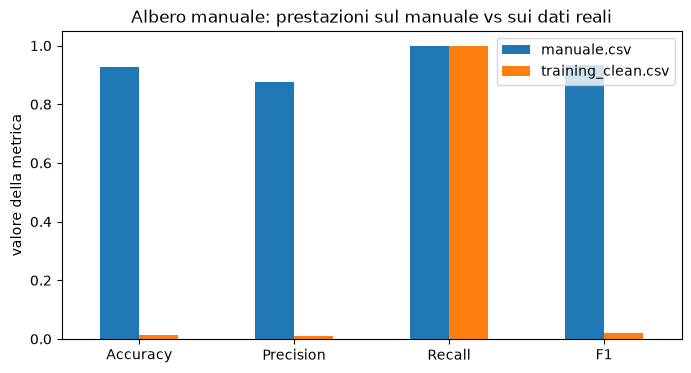

,manuale.csv,training_clean.csv
Accuracy,0.9286,0.0141
Precision,0.8750,0.0099
Recall,1.0000,0.9980
F1,0.9333,0.0195


In [9]:
# le metriche ottenute nel Task 2.1 sul file manuale (14 campioni)
sul_manuale = {"Accuracy": 0.9286, "Precision": 0.8750, "Recall": 1.0, "F1": 0.9333}
sul_training = {"Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1": f1}

confronto = pd.DataFrame({"manuale.csv": sul_manuale, "training_clean.csv": sul_training})

# grafico a barre affiancate (stile pandas)
confronto.plot(kind="bar", figsize=(8, 4), rot=0,
               title="Albero manuale: prestazioni sul manuale vs sui dati reali")
plt.ylabel("valore della metrica")
plt.show()

confronto.round(4)

## 4. Perché le prestazioni sono crollate

Dal grafico si vede che regge solo la recall, mentre le altre metriche crollano.
Le cause sono due, ed è importante tenerle distinte.

**Prima causa: overfitting sui 14 campioni.** Il secondo e il terzo split dell'albero
erano stati scelti per isolare singoli campioni del manuale (foglie da 1 elemento).
Soglie così specifiche non descrivono il fenomeno del dropout, descrivono quei due
campioni. Era il rischio già segnalato nell'analisi critica del Task 2.1.

**Seconda causa: il bilanciamento del manuale non vale sui dati reali.** `manuale.csv`
era stato costruito bilanciato 7+7 (era necessario: senza esempi di dropout non si
poteva costruire nulla a mano). Così però la classe dropout risultava il 50% dei
campioni, mentre in realtà è circa l'1%. La foglia di default era stata etichettata
"dropout" perché nel manuale conteneva 7 campioni su 8 di classe 1, ma nella stessa
regione, sui dati veri, la stragrande maggioranza delle osservazioni è di classe 0.
In sintesi: l'etichetta di maggioranza calcolata su un campione bilanciato non resta
valida quando le proporzioni vere sono diverse.

La recall al 99.8%, da sola, non è un merito: un modello che predice "dropout" quasi
sempre prende quasi tutti i dropout per forza. Lo verificheremo meglio nella sezione 5.

## 5. Tentativo di ottimizzazione

La consegna chiede di cercare di ottimizzare le prestazioni. Proviamo due strade,
entrambe giustificate dai dati.

### 5.1 Correggere l'etichetta della foglia

Se il problema è l'etichetta di maggioranza, si potrebbe correggerla usando le
proporzioni reali. Però con P(dropout) ≈ 1%, in ogni foglia dell'albero la maggioranza
reale è la classe 0: l'albero "corretto" direbbe sempre 0. Ci aspettiamo accuracy
altissima ma recall zero. Verifichiamo:

In [10]:
# il "sempre 0": ciò in cui degenera l'albero con le etichette corrette
TN_z = (df["LABEL"] == 0).sum()   # azzecca tutti gli 0...
FN_z = (df["LABEL"] == 1).sum()   # ...e manca tutti i dropout

acc_zero = TN_z / len(df)
print(f"'Sempre 0' -> Accuracy: {acc_zero:.4f}   Recall: 0   Precision: 0   F1: 0")

'Sempre 0' -> Accuracy: 0.9902   Recall: 0   Precision: 0   F1: 0


Come previsto: accuracy 99% ma recall e F1 pari a zero, cioè non trova nessun dropout.
Questo esperimento è comunque utile perché mostra una cosa importante: il nostro albero
(accuracy 1.4%) e il modello banale "sempre 0" (accuracy 99%) hanno accuracy
opposte, ma entrambi hanno F1 quasi nullo e sono entrambi inutilizzabili. Su classi
sbilanciate l'accuracy non è un criterio affidabile: da qui in poi ragioniamo sull'F1.

### 5.2 Usare le informazioni dell'EDA

Nel Task 3 avevamo visto che **FEATURE1** è la feature più legata al dropout, ma il
nostro albero non la usa. Il motivo è che sui 14 campioni del manuale era quasi
costante (13 valori identici su 14) e non offriva nessuna soglia possibile: quel
segnale si vede solo con un campione grande.

Verifichiamo sul training quanto FEATURE1 separa davvero le classi, confrontando il
tasso di dropout sopra e sotto la soglia 0.8365 (il punto medio tra i suoi due valori
dominanti, −0.4357 e 2.1087). Per confronto calcoliamo anche il tasso di dropout nella
regione che l'albero originale classifica come "dropout".

In [11]:
# tasso di dropout = media della colonna LABEL (le label sono 0/1,
# quindi la media è la frazione di 1) espressa in percentuale
tasso_globale = df["LABEL"].mean() * 100

# nella regione che l'albero classifica "dropout" (la sua foglia di default)
in_foglia = (df["FEATURE2"] <= 3.1129) & (df["FEATURE0"] <= 7.7685) & (df["FEATURE3"] <= 4.9501)
tasso_foglia = df[in_foglia]["LABEL"].mean() * 100

# sopra e sotto la soglia di FEATURE1
tasso_f1_alta  = df[df["FEATURE1"] > 0.8365]["LABEL"].mean() * 100
tasso_f1_bassa = df[df["FEATURE1"] <= 0.8365]["LABEL"].mean() * 100

print(f"tasso di dropout globale:                  {tasso_globale:.2f}%")
print(f"tasso nella regione 'dropout' dell'albero: {tasso_foglia:.2f}%")
print(f"tasso con FEATURE1 alta  (> 0.8365):       {tasso_f1_alta:.2f}%")
print(f"tasso con FEATURE1 bassa (<= 0.8365):      {tasso_f1_bassa:.2f}%")

tasso di dropout globale:                  0.98%
tasso nella regione 'dropout' dell'albero: 0.99%
tasso con FEATURE1 alta  (> 0.8365):       2.36%
tasso con FEATURE1 bassa (<= 0.8365):      0.63%


Dai numeri emergono due cose:

1. nella regione che l'albero classifica come "dropout" il tasso di dropout è
   praticamente uguale a quello globale (~1%): le soglie dell'albero non individuano
   una zona dove i dropout sono più concentrati, quindi non aggiungono informazione
   utile;
2. dove FEATURE1 è alta il tasso di dropout è circa 4 volte più alto rispetto a dove
   è bassa: questa condizione separa davvero le classi.

Costruiamo quindi la versione ottimizzata: una regola con soglia su FEATURE1.

In [12]:
# versione ottimizzata: il segnale dell'EDA al posto delle soglie del manuale
df["PREDETTA_OTT"] = (df["FEATURE1"] > 0.8365).astype(int)

# stessi conteggi di prima, sulla nuova predizione
TP2 = ((df["LABEL"] == 1) & (df["PREDETTA_OTT"] == 1)).sum()
TN2 = ((df["LABEL"] == 0) & (df["PREDETTA_OTT"] == 0)).sum()
FP2 = ((df["LABEL"] == 0) & (df["PREDETTA_OTT"] == 1)).sum()
FN2 = ((df["LABEL"] == 1) & (df["PREDETTA_OTT"] == 0)).sum()

pd.DataFrame([[TN2, FP2], [FN2, TP2]],
             index=["Reale 0", "Reale 1"],
             columns=["Predetta 0", "Predetta 1"])

,Predetta 0,Predetta 1
Reale 0,39439,9870
Reale 1,251,239


In [13]:
accuracy2  = (TP2 + TN2) / len(df)
precision2 = TP2 / (TP2 + FP2)
recall2    = TP2 / (TP2 + FN2)
f12        = 2 * precision2 * recall2 / (precision2 + recall2)

# tabella riassuntiva delle tre varianti provate in questo notebook
riepilogo = pd.DataFrame({
    "Albero Task 2.1":   [accuracy, precision, recall, f1],
    "Sempre 0":          [acc_zero, 0, 0, 0],
    "Regola FEATURE1":   [accuracy2, precision2, recall2, f12],
}, index=["Accuracy", "Precision", "Recall", "F1"])

riepilogo.round(4)

,Albero Task 2.1,Sempre 0,Regola FEATURE1
Accuracy,0.0141,0.9902,0.7968
Precision,0.0099,0.0000,0.0236
Recall,0.9980,0.0000,0.4878
F1,0.0195,0.0000,0.0451


## 6. Confronto tra le due versioni

La regola su FEATURE1 ottiene un F1 più che doppio rispetto all'albero originale
(0.045 contro 0.019). L'accuracy sale dall'1.4% all'80% perché i falsi positivi
scendono da circa 49.000 a circa 9.900.

In cambio la recall scende dal 99.8% al 48.8%: il modello segnala molti meno casi,
quindi trova meno dropout, ma quando li segnala sbaglia meno spesso. È il compromesso
tra precision e recall: migliorare una delle due di solito peggiora l'altra, e bisogna
scegliere in base a quale errore costa di più (un falso allarme o un dropout mancato).

Detto questo, anche la versione ottimizzata resta debole in assoluto: un F1 del 4.5%
è comunque basso. Con una sola condizione non si riesce a fare di meglio: servirebbe
combinare più feature insieme, che è quello che faranno i modelli del Task 5.

## 7. Conclusioni

Da questo task abbiamo imparato quattro cose:

- Il 13/14 del Task 2.1 non voleva dire molto, perché l'albero era valutato sugli
  stessi campioni con cui era stato costruito. Sui dati nuovi l'F1 è passato da 0.93
  a 0.02. Per questo nel Task 5 i dati verranno separati in train e test.
- Il crollo ha due cause diverse, da non confondere: le soglie erano troppo adattate
  ai 14 campioni del manuale (overfitting), e l'etichetta della foglia di default era
  stata decisa su un campione bilanciato 7+7 che non rispecchia le proporzioni reali
  delle classi (99/1).
- Su questo dataset l'accuracy non è una metrica affidabile: l'albero ha accuracy 1.4%,
  il "sempre 0" ha accuracy 99%, ma tutti e due hanno F1 praticamente nullo e non
  servono a niente. Nel Task 5 la metrica di riferimento sarà l'F1 della classe
  minoritaria.
- Il miglioramento è arrivato grazie a FEATURE1, individuata nell'analisi esplorativa
  del Task 3: nei 14 campioni del manuale era quasi costante (e quindi inutilizzabile),
  mentre sul dataset grande è la feature più informativa. Segno che certi pattern si
  vedono solo con abbastanza dati.
